In [29]:
import pandas as pd
import re

# Load your dataset
df = pd.read_csv("/Users/Sai/dataset_final.csv")

# Define a simple stopword list
basic_stopwords = {
    'a', 'an', 'the', 'and', 'or', 'is', 'are', 'was', 'were', 'to', 'of', 'in',
    'for', 'on', 'with', 'at', 'by', 'from', 'up', 'about', 'into', 'over', 'after',
    'under', 'again', 'further', 'then', 'once', 'here', 'there', 'all', 'any',
    'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor',
    'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 'can', 'will', 'just'
}

# Define the cleaning function
def clean_text_basic(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", '', text)  # Remove URLs
    text = re.sub(r"@\w+|#\w+", '', text)       # Remove mentions/hashtags
    text = re.sub(r"[^a-z\s]", '', text)        # Remove punctuation and numbers
    words = text.split()
    words = [word for word in words if word not in basic_stopwords]
    return ' '.join(words)

# Apply to dataset
df['clean_text'] = df['text'].apply(clean_text_basic)

# Save the cleaned data
df.to_csv("dataset_cleaned.csv", index=False)


In [30]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pandas as pd

# Load your cleaned data
df = pd.read_csv("dataset_cleaned.csv")

# Tokenizer settings
vocab_size = 5000  # Maximum number of words to keep
max_len = 30       # Max sequence length
oov_token = "<OOV>"

# Initialize tokenizer
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_token)
tokenizer.fit_on_texts(df['clean_text'])

# Convert text to sequences of integers
sequences = tokenizer.texts_to_sequences(df['clean_text'])

# Pad sequences to uniform length
padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post', truncating='post')

# Prepare labels
labels = df['label'].values

# Optional: Save padded sequences and labels
import numpy as np
np.save("padded_sequences.npy", padded_sequences)
np.save("labels.npy", labels)


In [31]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

# Load preprocessed data
padded_sequences = np.load("padded_sequences.npy")
labels = np.load("labels.npy")

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    padded_sequences, labels, test_size=0.2, random_state=42
)

# Model parameters
vocab_size = 5000
embedding_dim = 64
max_len = padded_sequences.shape[1]

# Define the model
model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
model.compile(loss='binary_crossentropy', optimizer=Adam(1e-3), metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_val, y_val))


Epoch 1/5


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6936 - loss: 0.6347 - val_accuracy: 0.7077 - val_loss: 0.5498
Epoch 2/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7534 - loss: 0.4950 - val_accuracy: 0.7455 - val_loss: 0.5388
Epoch 3/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8545 - loss: 0.3375 - val_accuracy: 0.7469 - val_loss: 0.5539
Epoch 4/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9293 - loss: 0.1902 - val_accuracy: 0.7524 - val_loss: 0.6175
Epoch 5/5
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9597 - loss: 0.1307 - val_accuracy: 0.7399 - val_loss: 0.7849


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

           0       0.57      0.46      0.51       211
           1       0.79      0.86      0.82       504

    accuracy                           0.74       715
   macro avg       0.68      0.66      0.67       715
weighted avg       0.73      0.74      0.73       715



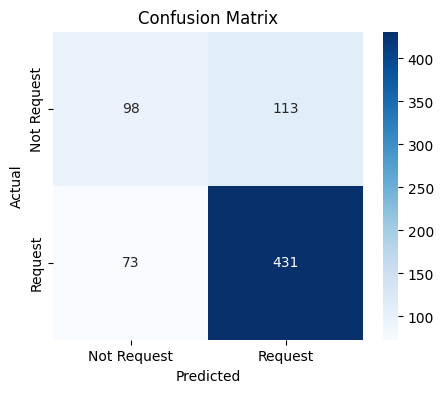

In [32]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on validation set
y_pred_probs = model.predict(X_val)
y_pred = (y_pred_probs > 0.5).astype(int)

# Print evaluation report
print(classification_report(y_val, y_pred))

# Plot confusion matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Request', 'Request'], yticklabels=['Not Request', 'Request'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [33]:
# Example new tweet
new_tweet = "Need food and water urgently in Chennai!"

# Clean the tweet using the same logic as before
def clean_text_basic(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", '', text)
    text = re.sub(r"@\w+|#\w+", '', text)
    text = re.sub(r"[^a-z\s]", '', text)
    words = text.split()
    basic_stopwords = {
        'a', 'an', 'the', 'and', 'or', 'is', 'are', 'was', 'were', 'to', 'of', 'in',
        'for', 'on', 'with', 'at', 'by', 'from', 'up', 'about', 'into', 'over', 'after',
        'under', 'again', 'further', 'then', 'once', 'here', 'there', 'all', 'any',
        'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor',
        'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 'can', 'will', 'just'
    }
    words = [word for word in words if word not in basic_stopwords]
    return ' '.join(words)

# Preprocess and tokenize
cleaned = clean_text_basic(new_tweet)
seq = tokenizer.texts_to_sequences([cleaned])
padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')

# Predict
prediction = model.predict(padded)[0][0]
print(f"Probability of being a disaster-related supply request: {prediction:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Probability of being a disaster-related supply request: 0.77


In [34]:
# Step 7: Save model and tokenizer
import pickle
model.save("disaster_rnn_model.h5")

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("✅ Model and tokenizer saved!")

✅ Model and tokenizer saved!


In [35]:
!pip install tensorflow





[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [36]:
import sys
!{sys.executable} -m pip install tensorflow



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [37]:
import sys
!{sys.executable} -m pip install scikit-learn



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python3.12 -m pip install --upgrade pip
